In [3]:
import pandas as pd
df = pd.read_csv('quebec_housing_sales_v2.csv')
print(df.shape)
print(df.info())
print(df.head())


(5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       5000 non-null   int64  
 1   city              5000 non-null   str    
 2   neighborhood      5000 non-null   str    
 3   property_type     5000 non-null   str    
 4   bedrooms          5000 non-null   int64  
 5   bathrooms         5000 non-null   int64  
 6   living_area_sqft  5000 non-null   int64  
 7   lot_size_sqft     3789 non-null   float64
 8   year_built        5000 non-null   int64  
 9   renovation_year   1592 non-null   float64
 10  garage            5000 non-null   str    
 11  basement          5000 non-null   str    
 12  sale_year         5000 non-null   int64  
 13  sale_price        5000 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 547.0 KB
None
   property_id            city         neighborhood  property_type  bedrooms

In [4]:
print(df.isnull().sum())


property_id            0
city                   0
neighborhood           0
property_type          0
bedrooms               0
bathrooms              0
living_area_sqft       0
lot_size_sqft       1211
year_built             0
renovation_year     3408
garage                 0
basement               0
sale_year              0
sale_price             0
dtype: int64


In [5]:
df = df.drop(columns=['renovation_year', 'property_id'])
df = df.dropna()
print(df.isnull().sum())

city                0
neighborhood        0
property_type       0
bedrooms            0
bathrooms           0
living_area_sqft    0
lot_size_sqft       0
year_built          0
garage              0
basement            0
sale_year           0
sale_price          0
dtype: int64


In [6]:
df.info()
df.describe()
df.shape
df.columns
print(df.describe(include='all'))

<class 'pandas.DataFrame'>
Index: 3789 entries, 0 to 4998
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              3789 non-null   str    
 1   neighborhood      3789 non-null   str    
 2   property_type     3789 non-null   str    
 3   bedrooms          3789 non-null   int64  
 4   bathrooms         3789 non-null   int64  
 5   living_area_sqft  3789 non-null   int64  
 6   lot_size_sqft     3789 non-null   float64
 7   year_built        3789 non-null   int64  
 8   garage            3789 non-null   str    
 9   basement          3789 non-null   str    
 10  sale_year         3789 non-null   int64  
 11  sale_price        3789 non-null   int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 384.8 KB
            city  neighborhood  property_type     bedrooms    bathrooms  \
count       3789          3789           3789  3789.000000  3789.000000   
unique        32            72           

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
print(df.dtypes)
print(df.head())

city                    str
neighborhood            str
property_type           str
bedrooms              int64
bathrooms             int64
living_area_sqft      int64
lot_size_sqft       float64
year_built            int64
garage                  str
basement                str
sale_year             int64
sale_price            int64
dtype: object
             city         neighborhood  property_type  bedrooms  bathrooms  \
0     Châteauguay         Centre-Ville      Townhouse         3          2   
1  Trois-Rivières  Cap-de-la-Madeleine         Duplex         4          4   
2           Lévis               Charny      Townhouse         3          1   
3           Laval           Fabreville  Single Family         3          3   
5   Victoriaville         Centre-Ville  Single Family         4          3   

   living_area_sqft  lot_size_sqft  year_built garage basement  sale_year  \
0              1160         2304.0        2022    Yes       No       2024   
1              1807        

C:\Users\sragu\AppData\Local\Temp\ipykernel_20204\1213794441.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [9]:
df['basement'] = df['basement'].astype(str).str.strip().str.lower()
df['garage']   = df['garage'].astype(str).str.strip().str.lower()



print(df[['basement','garage']].head(5))

print("Basement unique values:", df['basement'].unique())

print("Garage unique values:", df['garage'].unique())
print("Property type unique values:", df['property_type'].unique())
print("City unique values:", df['city'].unique())
print("Neighborhood unique values:", df['neighborhood'].unique())

  basement garage
0       no    yes
1      yes     no
2      yes    yes
3      yes    yes
5      yes    yes
Basement unique values: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Garage unique values: <StringArray>
['yes', 'no']
Length: 2, dtype: str
Property type unique values: <StringArray>
['Townhouse', 'Duplex', 'Single Family', 'Bungalow', 'Triplex']
Length: 5, dtype: str
City unique values: <StringArray>
[               'Châteauguay',             'Trois-Rivières',
                      'Lévis',                      'Laval',
              'Victoriaville',                   'Montréal',
                 'Sherbrooke',               'Saint-Jérôme',
                  'Longueuil',                    'Mirabel',
                   'Val-d'Or',                   'Gatineau',
                 'Blainville',                     'Québec',
              'Drummondville',   'Saint-Jean-sur-Richelieu',
           'Vaudreuil-Dorion',                   'Brossard',
              'Rouyn-Noranda',    

C:\Users\sragu\AppData\Local\Temp\ipykernel_20204\3540174978.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns


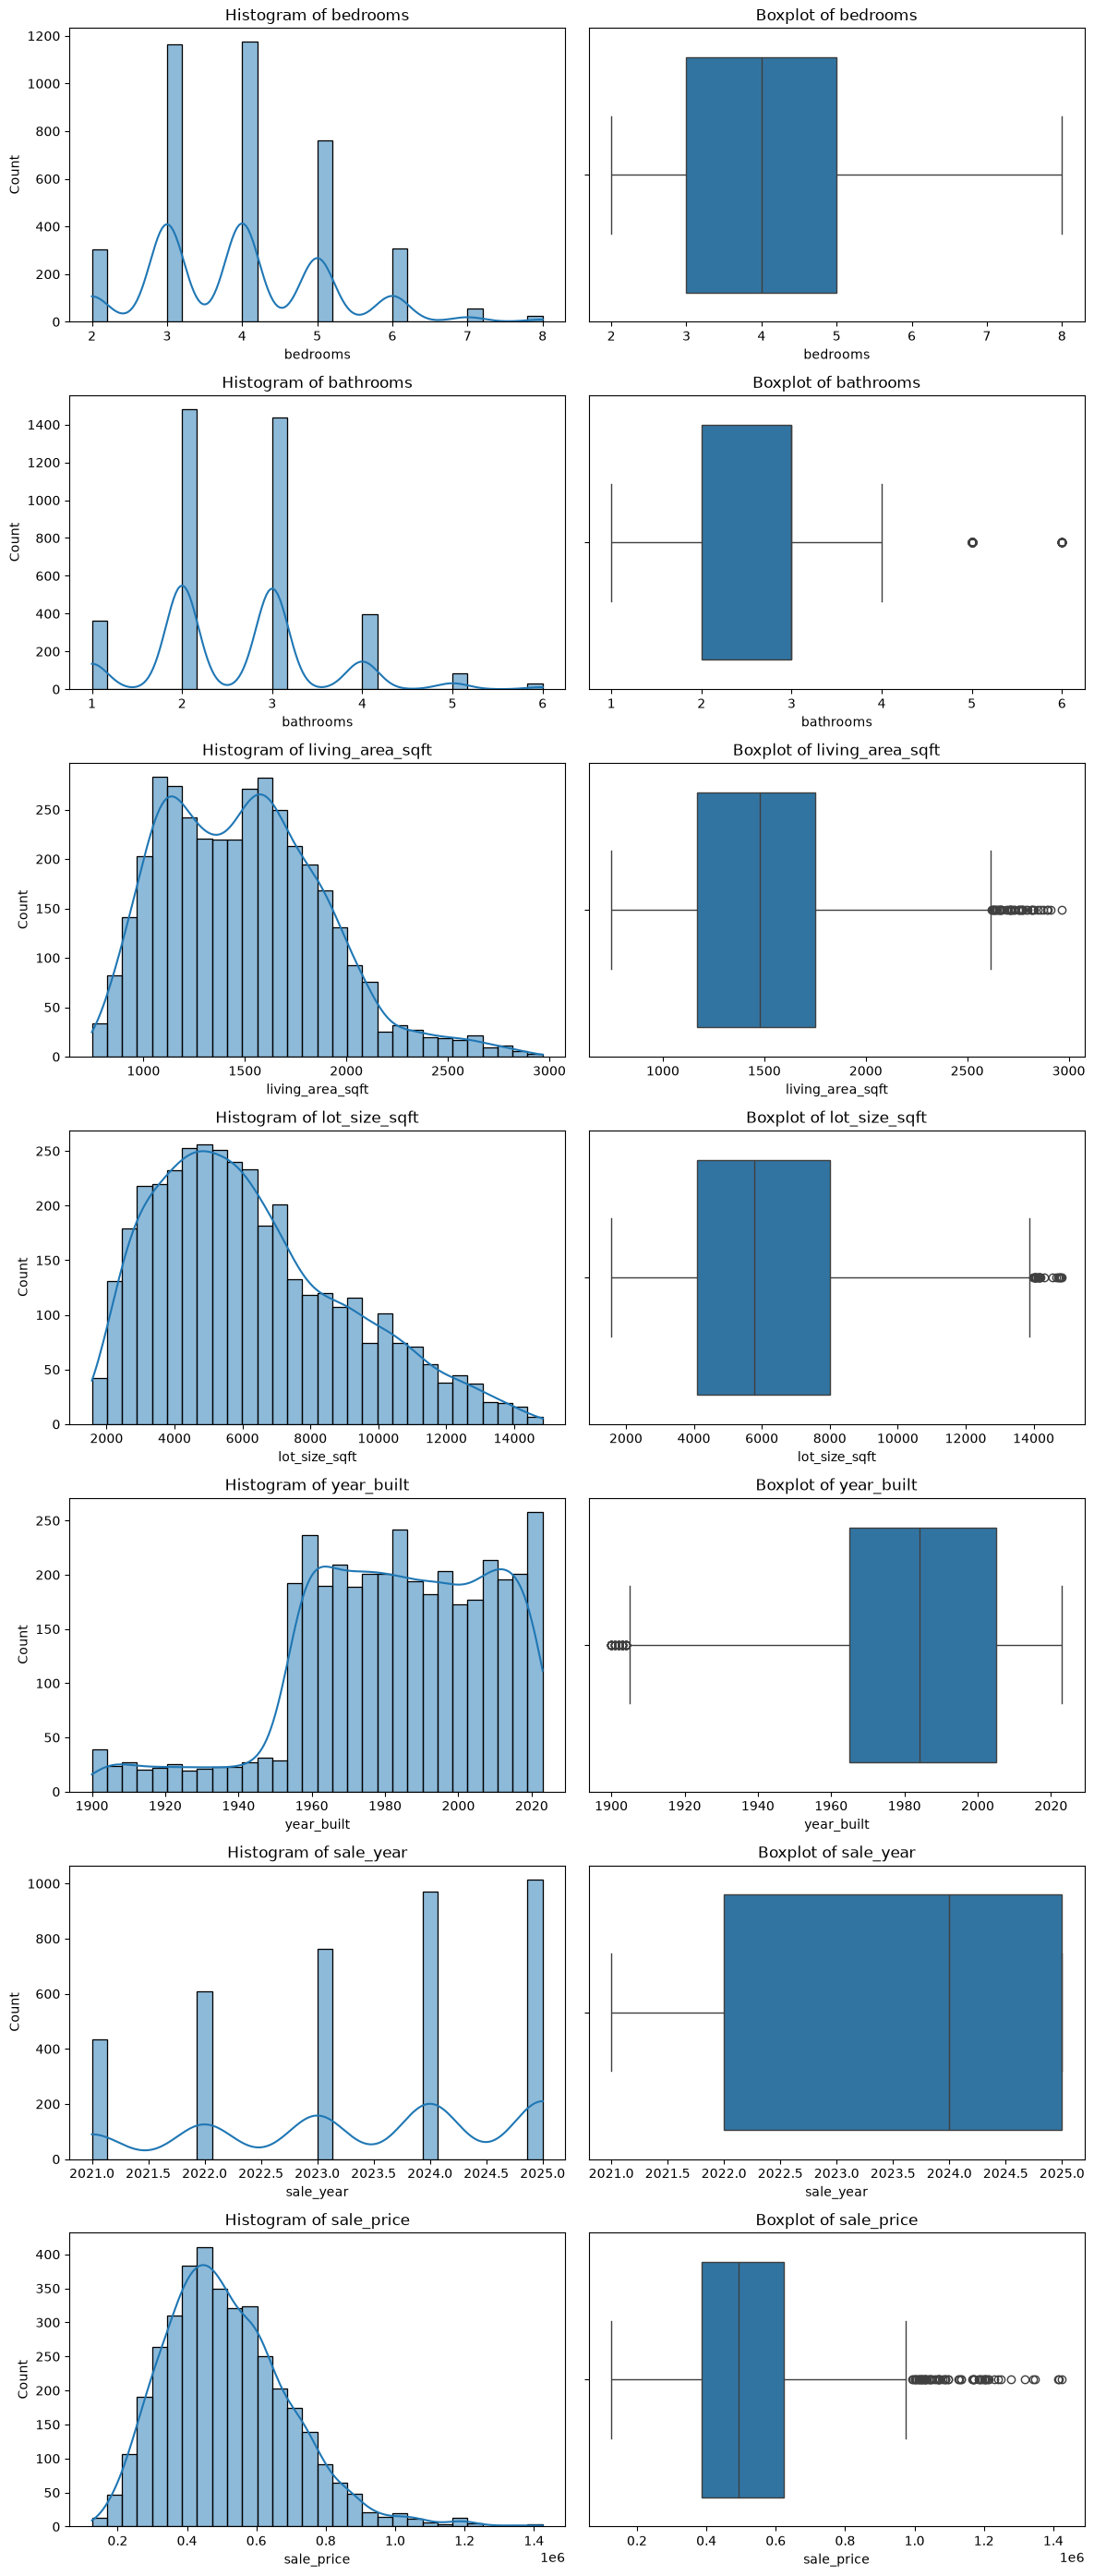

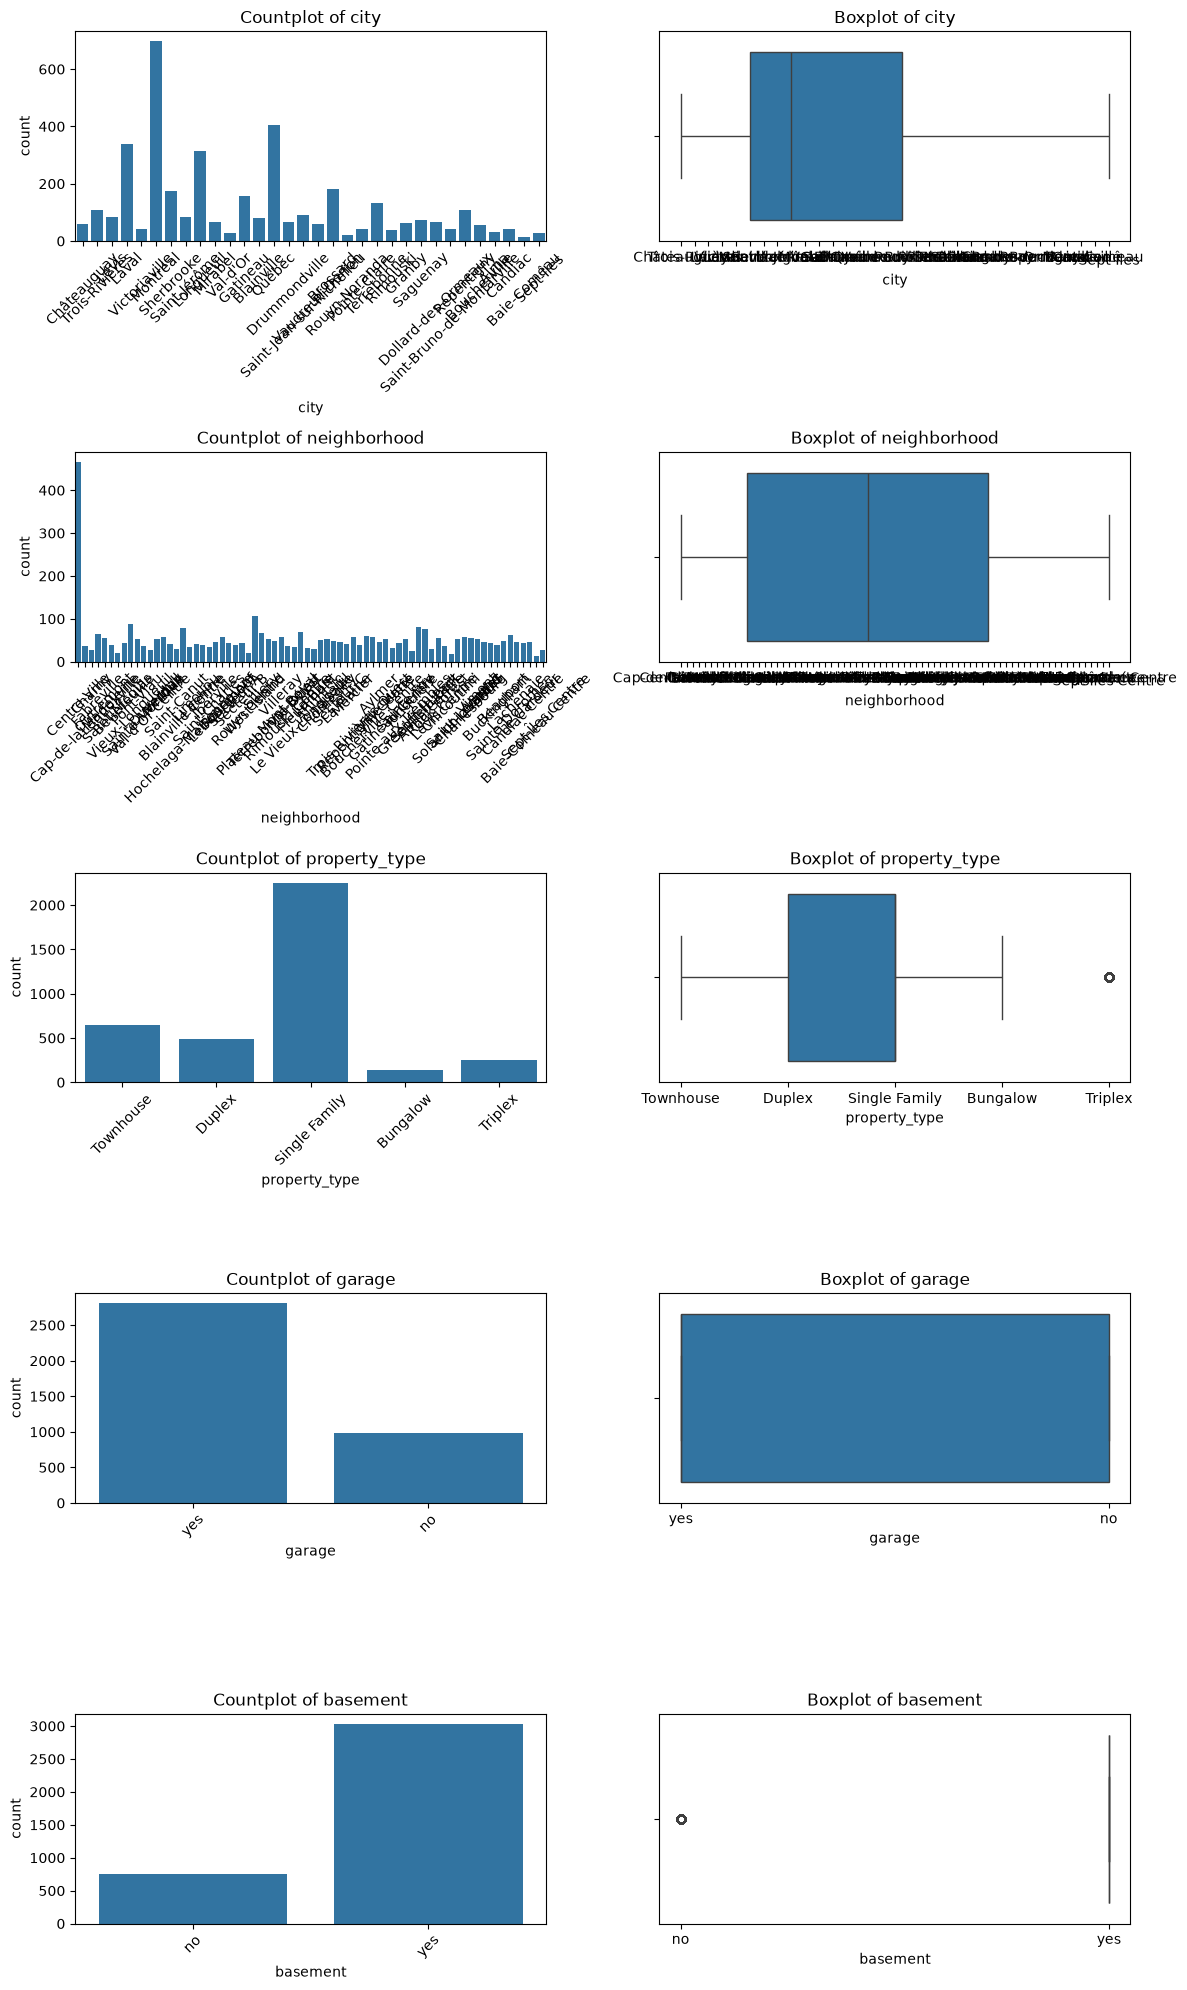

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

rows = len(num_cols)
fig, axes = plt.subplots(rows, 2, figsize=(12, 4*rows))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i,0])
    axes[i,0].set_title(f"Histogram of {col}")

    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig("numeric_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

rows = len(cat_cols)
fig, axes = plt.subplots(rows, 2, figsize=(12, 4*rows))

for j, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[j,0])
    axes[j,0].set_title(f"Countplot of {col}")
    axes[j,0].tick_params(axis='x', rotation=45)

    sns.boxplot(x=df[col], ax=axes[j,1])
    axes[j,1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig("categorical_distributions.png", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
df.to_csv('quebec_housing_sales_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
